<a href="https://colab.research.google.com/github/hafizihsani/data-science-2026/blob/main/Pertemuan9_Muhammad_Hafiz_ihsani_250401020155.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pertemuan 9 — Algoritma Klasifikasi (Bagian 1) **
Nama : Muhammad Hafiz Ihsani

NIM : 250401020155

Mata Kuliah: Data Science — S1 PJJ Informatika

Kelas: IF401

# Langkah 1: Load & EDA Singkat

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Memuat dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0=malignant (ganas), 1=benign (jinak)

# Menampilkan bentuk data dan distribusi target
print('Shape:', X.shape)
print('\nDistribusi target (Proporsi):')
print(pd.Series(y).value_counts(normalize=True).round(3))
print("\nKeterangan Target: 0 = Malignant, 1 = Benign")

Shape: (569, 30)

Distribusi target (Proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64

Keterangan Target: 0 = Malignant, 1 = Benign


#Langkah 2: Preprocessing



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split 80:20 dengan stratifikasi agar distribusi target seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standarisasi Fitur (Wajib untuk Logistic Regression, Opsional untuk Decision Tree)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 455
Jumlah data testing: 114


# Langkah 3: Latih Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan melatih model Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

# Menampilkan fitur yang paling berpengaruh berdasarkan nilai absolut koefisien
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===")
print(coef_df.head())

=== 5 Fitur Paling Berpengaruh (Logistic Regression) ===
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


# Langkah 4: Latih Decision Tree

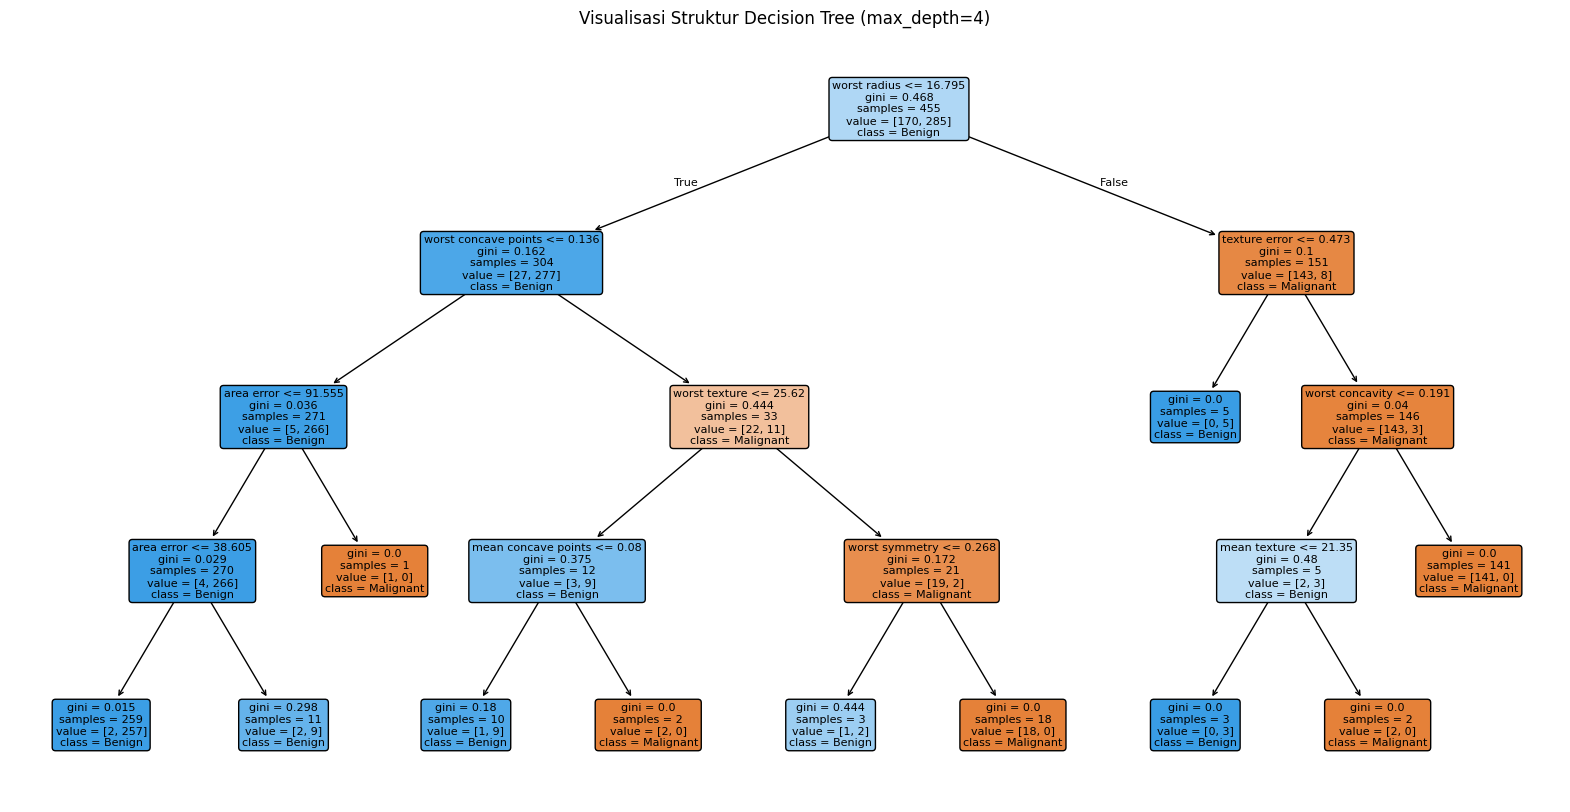

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Inisialisasi dan melatih model Decision Tree (Menggunakan data asli tanpa scaling)
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Visualisasi pohon keputusan
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True, rounded=True)
plt.title("Visualisasi Struktur Decision Tree (max_depth=4)")
plt.show()

#Langkah 5: Evaluasi & Bandingkan

In [5]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

# Loop untuk menghitung metrik evaluasi kedua model
for name, y_pred in [('Logistic Regression', y_pred_log),
                     ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy : 0.982
Precision: 0.986
Recall    : 0.986
F1-Score  : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy : 0.939
Precision: 0.958
Recall    : 0.944
F1-Score  : 0.951


#Analisis & Pembahasan

>**1. Mengapa Recall Menjadi Metrik Paling Kritis dalam Diagnosis Kanker?**

 Dalam domain medis, khususnya diagnosis kanker, Recall jauh lebih penting dibandingkan Accuracy semata.  Recall mengukur seberapa baik model dalam mendeteksi seluruh pasien yang sebenarnya menderita kanker biner positif (malignant).  Jika Recall rendah, berarti terjadi banyak False Negative (pasien kanker aktual divonis sehat/jinak oleh model). Kesalahan False Negative ini sangat berbahaya karena keterlambatan penanganan medis berisiko mengancam nyawa pasien.  Sebaliknya, kesalahan False Positive (pasien sehat dikira kanker) hanya mengakibatkan pemeriksaan lanjutan (double-check) yang mendalam tanpa membahayakan nyawa secara langsung.  



> **2. Perbandingan Performa Model (Sesuai Karakteristik Umum Data)  **

 Logistic Regression umumnya menghasilkan nilai Recall yang lebih tinggi dan stabil pada jenis dataset ini karena memanfaatkan batas probabilitas kontinu di balik fungsi sigmoid untuk menangkap pola linier multivariat secara halus.  Decision Tree bekerja dengan melakukan partisi data yang kaku secara bertahap menggunakan batas garis lurus tegak lurus (orthogonal split). Pohon dengan kedalaman terbatas (max_depth=4) terkadang melakukan underdiagnose pada titik marginal sehingga berisiko menghasilkan False Negative yang sedikit lebih tinggi daripada Logistic Regression.



>  **Kesimpulan Penilaian Praktikum:**

Untuk penanganan medis yang mengutamakan keselamatan jiwa (meminimalkan False Negative), Logistic Regression adalah pilihan model yang lebih baik dan direkomendasikan pada pengujian dataset ini karena keunggulannya dalam aspek metrik Recall.




